15543 697
round trips ok


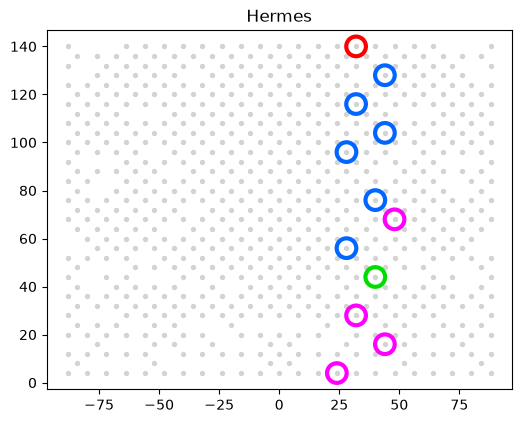

In [24]:
import sqlite3
import numpy as np
from board import *

conn = sqlite3.connect("tension.db")
holds = load_holds(conn)
data = load_data(conn)
hold_to_token, token_to_hold, VOCAB_SIZE = build_tokenizer(holds)

print(len(data), VOCAB_SIZE)

for f in data['frames']:
    assert decode(encode(f, hold_to_token), token_to_hold) == decode_frames(f)
print("round trips ok")

plot_climb(data['frames'].iloc[0], holds, data['name'].iloc[0])

In [25]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionHead(nn.Module):
    """One attention head. Same as before, just narrower."""
    def __init__(self, d_model, d_head):
        super().__init__()
        self.query = nn.Linear(d_model, d_head)
        self.key   = nn.Linear(d_model, d_head)
        self.value = nn.Linear(d_model, d_head)
        self.d_head = d_head

    def forward(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_head)

        T = x.shape[1]
        mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
        scores = scores.masked_fill(~mask, float('-inf'))

        weights = F.softmax(scores, dim=-1)
        return weights @ v

class MultiHeadAttention(nn.Module):
    """Several heads in parallel, glued back together.

    Each head gets d_model // n_heads dimensions, so the total width is
    unchanged — you're splitting the same capacity across independent views
    rather than adding any.
    """
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        d_head = d_model // n_heads
        self.heads = nn.ModuleList(
            [AttentionHead(d_model, d_head) for _ in range(n_heads)]
        )
        self.proj = nn.Linear(d_model, d_model)   # let the heads mix

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.proj(out)

In [26]:
mha = MultiHeadAttention(d_model=128, n_heads=4)
x = torch.randn(2, 42, 128)
print(mha(x).shape)     # torch.Size([2, 42, 128])

torch.Size([2, 42, 128])


In [27]:
class Block(nn.Module):
    """One transformer layer: attention, then per-position processing.

    Attention moves information between positions. The MLP then processes each
    position on its own. Both are wrapped in residual connections, so each
    sublayer adds to the running representation rather than replacing it.
    """
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

In [28]:
class ClimbGPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4, max_len=42):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)   # token number -> vector
        self.pos_emb   = nn.Embedding(max_len + 1, d_model)  # position -> vector
        self.cond      = nn.Linear(2, d_model)               # (angle, grade) -> vector

        self.blocks = nn.ModuleList(
            [Block(d_model, n_heads) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)           # -> score per token

    def forward(self, tokens, cond):
        # tokens: (B, T) integers.  cond: (B, 2) floats, angle and grade in 0-1.
        B, T = tokens.shape

        x = self.token_emb(tokens)                           # (B, T, d_model)

        # conditioning goes in as an extra position at the front
        c = self.cond(cond).unsqueeze(1)                      # (B, 1, d_model)
        x = torch.cat([c, x], dim=1)                          # (B, T+1, d_model)

        pos = torch.arange(T + 1, device=tokens.device)
        x = x + self.pos_emb(pos)                             # add position info

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        return self.head(x)                                   # (B, T+1, vocab_size)

In [29]:
model = ClimbGPT(VOCAB_SIZE)
print(sum(p.numel() for p in model.parameters()), "parameters")
out = model(torch.randint(0, VOCAB_SIZE, (2, 42)), torch.rand(2, 2))
print(out.shape)

978361 parameters
torch.Size([2, 43, 697])


In [30]:
MAX_LEN = 2 + 2 * MAX_HOLDS

def pad(tokens):
    return tokens + [PAD] * (MAX_LEN - len(tokens))

sequences = np.array([pad(encode(f, hold_to_token)) for f in data['frames']])
angles = (data['angle'].values / 70.0).astype(np.float32)
grades = (data['difficulty_average'].values / 40.0).astype(np.float32)

from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
idx_train, idx_val = next(gss.split(sequences, groups=data['uuid']))

print(sequences.shape, len(idx_train), len(idx_val))

(15543, 42) 14029 1514


In [31]:
# model = ClimbGPT(VOCAB_SIZE)
# opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

# X = torch.tensor(sequences[idx_train], dtype=torch.long)
# C = torch.tensor(np.stack([angles[idx_train], grades[idx_train]], axis=1))

# for epoch in range(20):
#     perm = torch.randperm(len(X))
#     total, nb = 0.0, 0
#     for i in range(0, len(X), 64):
#         batch = perm[i:i+64]
#         tokens, cond = X[batch], C[batch]

#         logits = model(tokens, cond)[:, :-1, :]

#         loss = F.cross_entropy(
#             logits.reshape(-1, VOCAB_SIZE),
#             tokens.reshape(-1),
#             ignore_index=PAD,
#         )

#         opt.zero_grad()
#         loss.backward()
#         opt.step()
#         total += loss.item()
#         nb += 1

#     print(epoch, round(total / nb, 4))

In [32]:
Xv = torch.tensor(sequences[idx_val], dtype=torch.long)
Cv = torch.tensor(np.stack([angles[idx_val], grades[idx_val]], axis=1))

model.eval()
with torch.no_grad():
    logits = model(Xv, Cv)[:, :-1, :]
    vl = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), Xv.reshape(-1), ignore_index=PAD)
model.train()
print("train 0.9756, val", round(vl.item(), 4))

train 0.9756, val 6.7364


In [33]:
Xv = torch.tensor(sequences[idx_val], dtype=torch.long)
Cv = torch.tensor(np.stack([angles[idx_val], grades[idx_val]], axis=1))

@torch.no_grad()
def val_loss():
    model.eval()
    logits = model(Xv, Cv)[:, :-1, :]
    l = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), Xv.reshape(-1), ignore_index=PAD)
    model.train()
    return l.item()


model = ClimbGPT(VOCAB_SIZE)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

X = torch.tensor(sequences[idx_train], dtype=torch.long)
C = torch.tensor(np.stack([angles[idx_train], grades[idx_train]], axis=1))

best_val = float('inf')

# for epoch in range(20):
#     perm = torch.randperm(len(X))
#     total, nb = 0.0, 0
#     for i in range(0, len(X), 64):
#         batch = perm[i:i+64]
#         tokens, cond = X[batch], C[batch]

#         logits = model(tokens, cond)[:, :-1, :]
#         loss = F.cross_entropy(
#             logits.reshape(-1, VOCAB_SIZE),
#             tokens.reshape(-1),
#             ignore_index=PAD,
#         )

#         opt.zero_grad()
#         loss.backward()
#         opt.step()
#         total += loss.item()
#         nb += 1

#     vl = val_loss()
#     if vl < best_val:
#         best_val = vl
#         torch.save(model.state_dict(), 'best_model.pt')
#     print(epoch, round(total / nb, 4), round(vl, 4))

In [34]:
model.load_state_dict(torch.load('best_model.pt'))
print("loaded best, val:", round(best_val, 4))

loaded best, val: inf


In [35]:
@torch.no_grad()
def generate(model, angle, grade, temperature=0.8, max_holds=20):
    model.eval()
    cond = torch.tensor([[angle / 70.0, grade / 40.0]], dtype=torch.float)
    tokens = torch.tensor([[BOS]], dtype=torch.long)

    used, n_start, n_finish = set(), 0, 0

    for _ in range(2 * max_holds):
        logits = model(tokens, cond)[0, -1].clone()

        expecting_role = (tokens.shape[1] % 2 == 0)

        if expecting_role:
            allowed = set(role_to_token.values())
            if n_start >= 2:
                allowed.discard(role_to_token[5])
            if n_finish >= 1:
                allowed.discard(role_to_token[7])
        else:
            allowed = set(token_to_hold.keys()) - used
            if len(used) >= 4 and n_start >= 1 and n_finish >= 1:
                allowed.add(EOS)

        mask = torch.full_like(logits, float('-inf'))
        for t in allowed:
            mask[t] = 0.0

        probs = F.softmax((logits + mask) / temperature, dim=-1)
        nxt = torch.multinomial(probs, 1).item()

        if nxt == EOS:
            break

        if nxt in token_to_hold:
            used.add(nxt)
        elif nxt == role_to_token[5]:
            n_start += 1
        elif nxt == role_to_token[7]:
            n_finish += 1

        tokens = torch.cat([tokens, torch.tensor([[nxt]])], dim=1)

    return decode(tokens[0].tolist() + [EOS], token_to_hold)

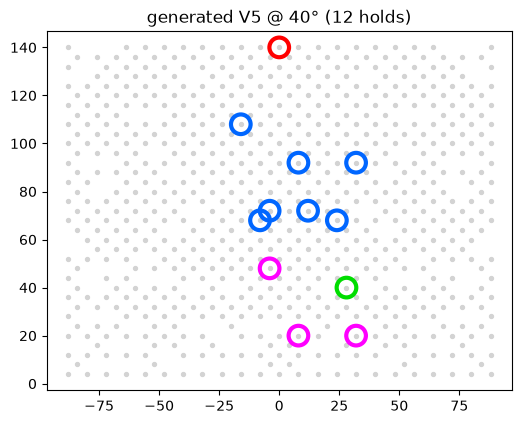

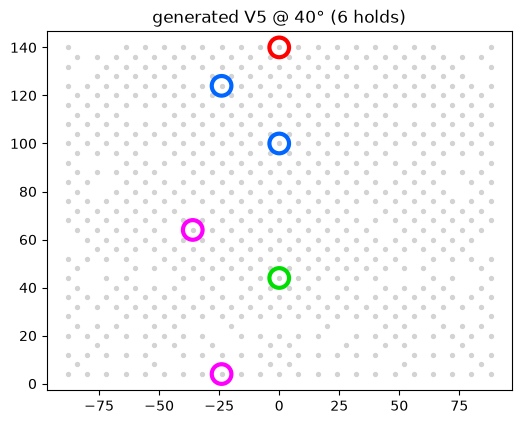

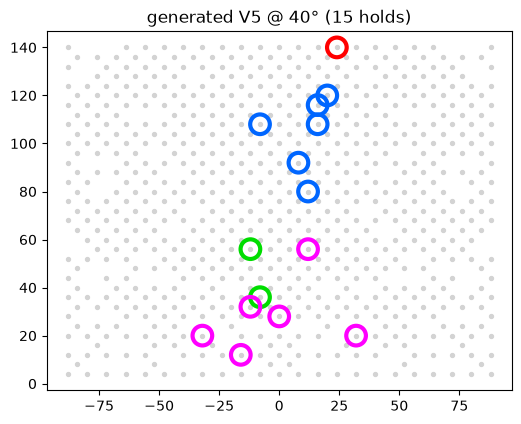

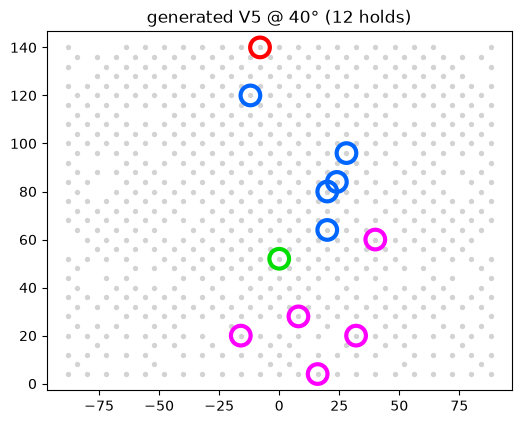

In [36]:
for i in range(4):
    climb = generate(model, angle=40, grade=20.0)
    plot_climb(climb, holds, f"generated V5 @ 40° ({len(climb)} holds)")

In [37]:
print(data['quality_average'].describe())

count    15543.000000
mean         2.805027
std          0.183415
min          1.200000
25%          2.739130
50%          2.839510
75%          2.928570
max          3.000000
Name: quality_average, dtype: float64


In [44]:
model = ClimbGPT(VOCAB_SIZE)
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

ClimbGPT(
  (token_emb): Embedding(697, 128)
  (pos_emb): Embedding(43, 128)
  (cond): Linear(in_features=2, out_features=128, bias=True)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x AttentionHead(
            (query): Linear(in_features=128, out_features=32, bias=True)
            (key): Linear(in_features=128, out_features=32, bias=True)
            (value): Linear(in_features=128, out_features=32, bias=True)
          )
        )
        (proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
        (3): Dropout(p=0.1, inplace=False)
      )

In [42]:
!cp best_model.pt base_model.pt

In [45]:
print(data['quality_average'].describe())

count    15543.000000
mean         2.805027
std          0.183415
min          1.200000
25%          2.739130
50%          2.839510
75%          2.928570
max          3.000000
Name: quality_average, dtype: float64


In [47]:
quality_mask = (train_mask
                & (data['quality_average'] >= 2.90).values
                & (data['ascensionist_count'] >= 20).values)
idx_quality = np.where(quality_mask)[0]
print(len(idx_quality))

1937


In [48]:
model.load_state_dict(torch.load('base_model.pt'))
opt = torch.optim.AdamW(model.parameters(), lr=3e-5)

Xq = torch.tensor(sequences[idx_quality], dtype=torch.long)
Cq = torch.tensor(np.stack([angles[idx_quality], grades[idx_quality]], axis=1))

for epoch in range(5):
    perm = torch.randperm(len(Xq))
    total, nb = 0.0, 0
    for i in range(0, len(Xq), 32):
        batch = perm[i:i+32]
        tokens, cond = Xq[batch], Cq[batch]
        logits = model(tokens, cond)[:, :-1, :]
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE),
                               tokens.reshape(-1), ignore_index=PAD)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item(); nb += 1

    torch.save(model.state_dict(), f'finetuned_epoch{epoch}.pt')
    print(epoch, round(total / nb, 4), round(val_loss(), 4))

0 1.5372 2.0344
1 1.5346 2.0432
2 1.5158 2.0523
3 1.5012 2.0585
4 1.4917 2.0662


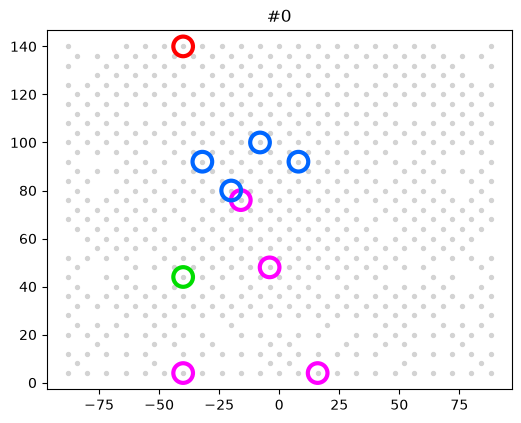

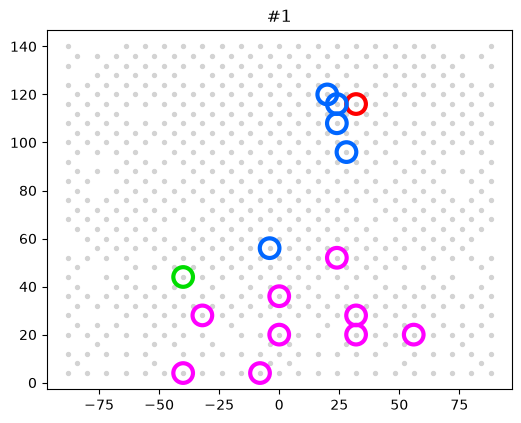

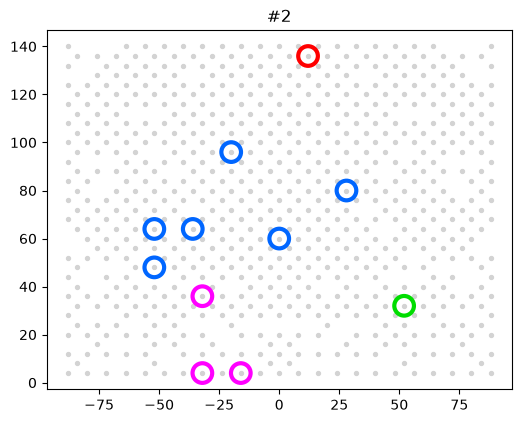

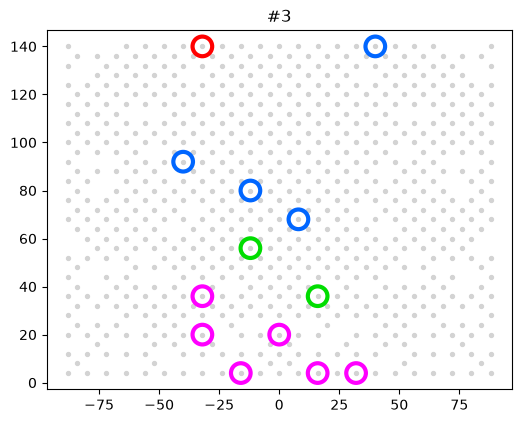

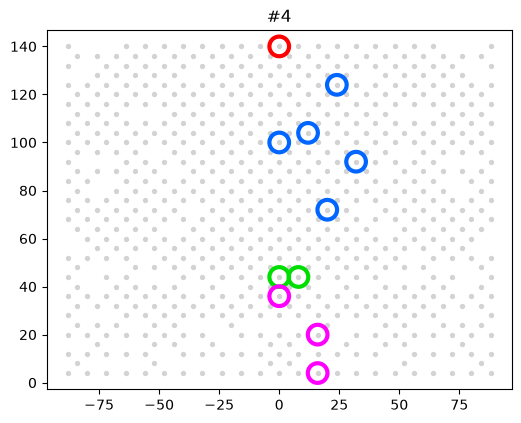

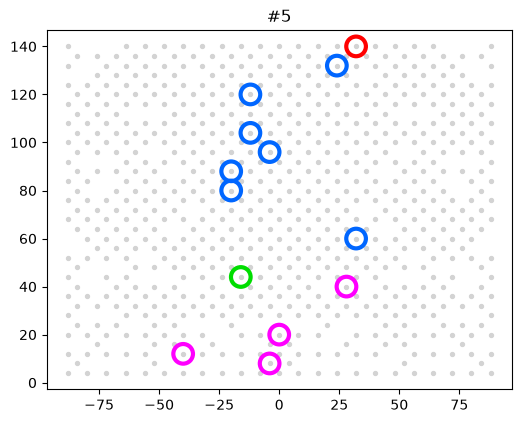

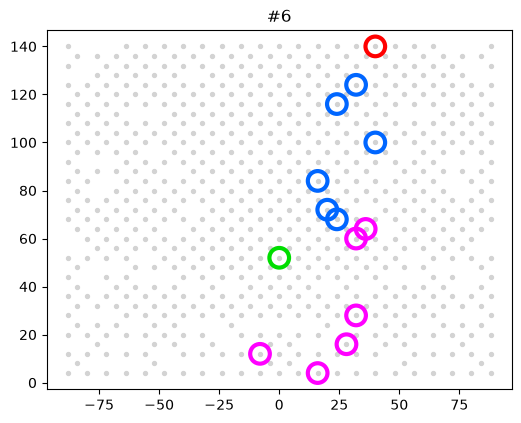

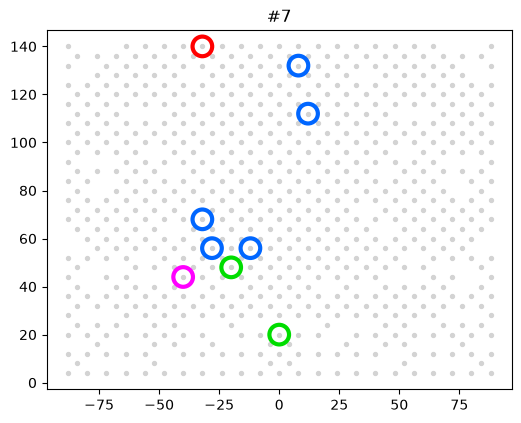

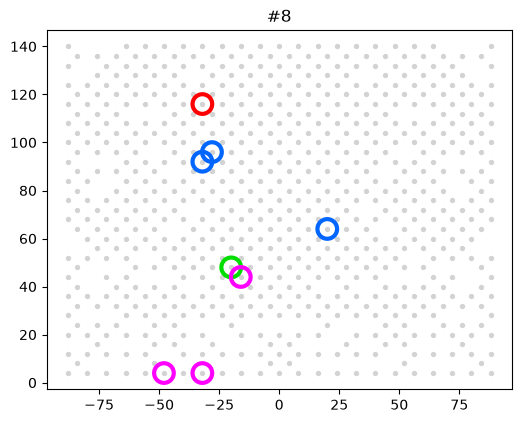

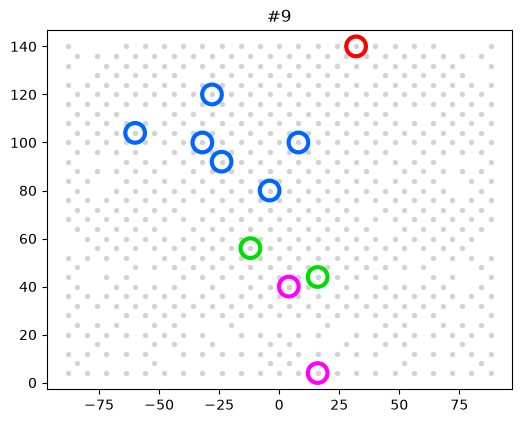

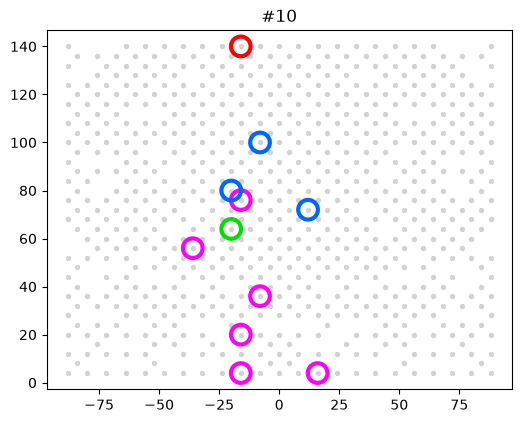

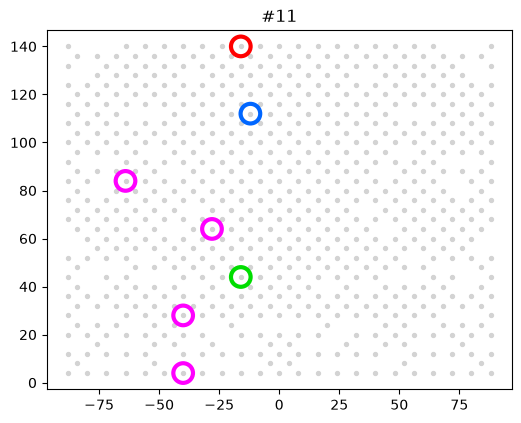

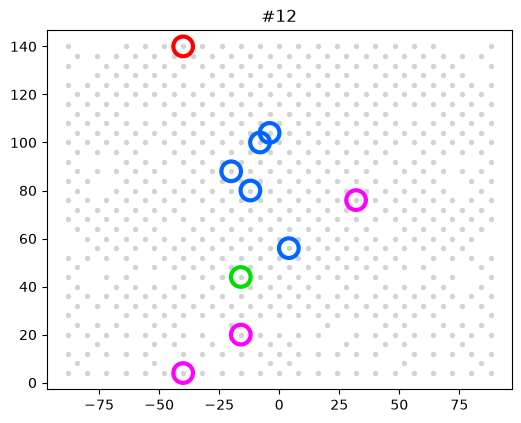

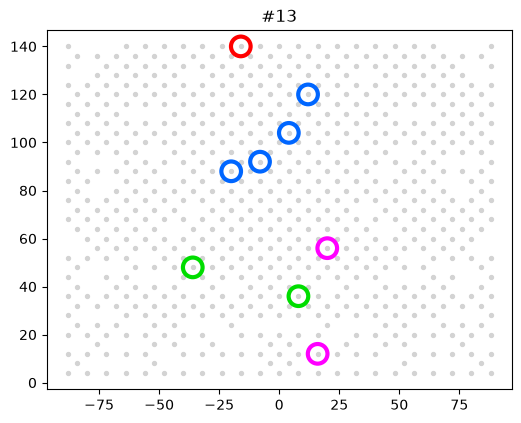

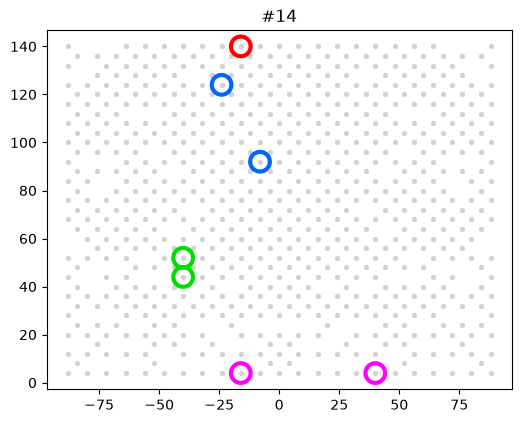

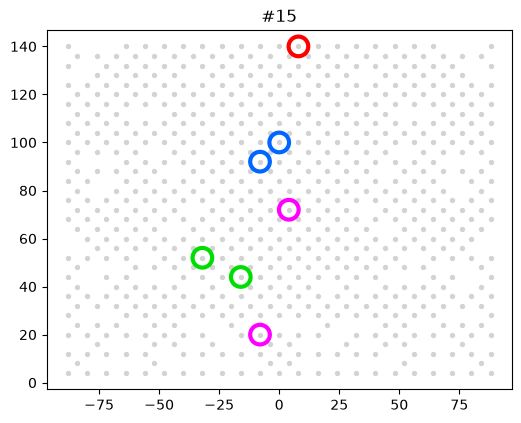

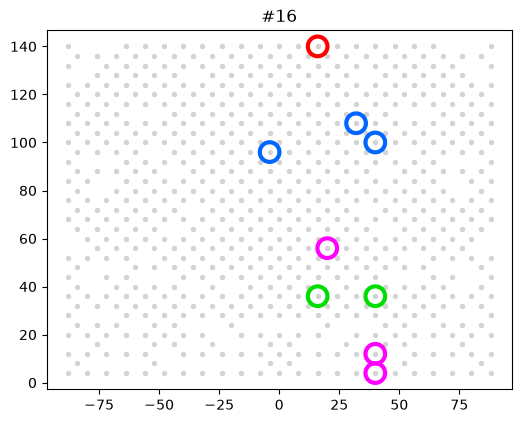

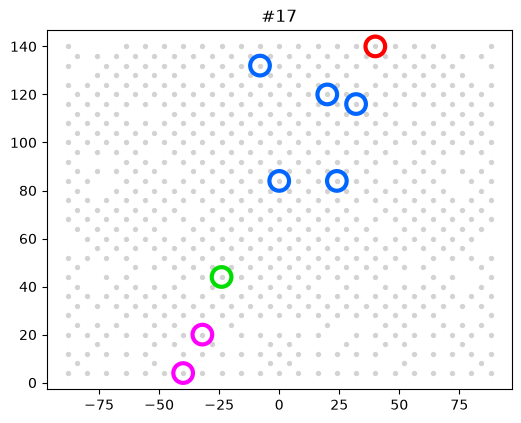

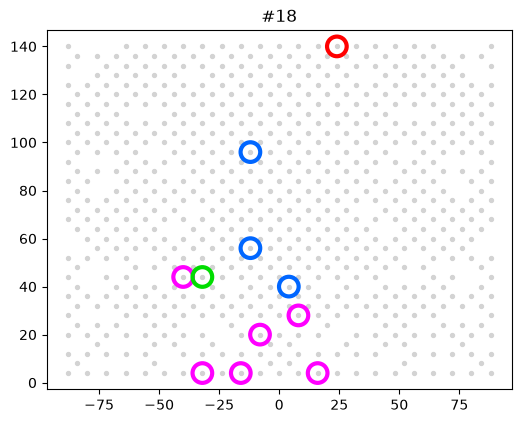

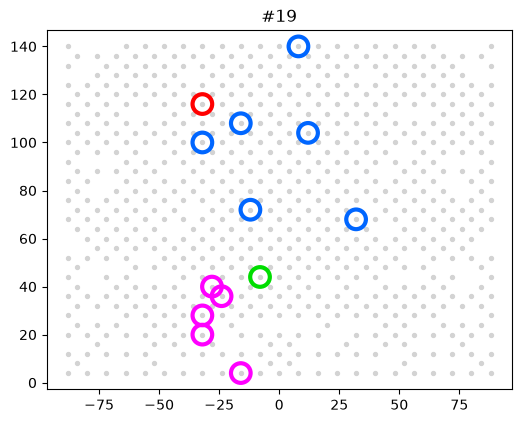

0 base
1 tuned
2 base
3 base
4 tuned
5 tuned
6 tuned
7 base
8 tuned
9 base
10 base
11 tuned
12 tuned
13 base
14 base
15 base
16 tuned
17 base
18 tuned
19 tuned


In [51]:
import random

pairs = [(generate(base, 40, 20.0), 'base') for _ in range(10)] + \
        [(generate(tuned, 40, 20.0), 'tuned') for _ in range(10)]
random.shuffle(pairs)

for i, (climb, label) in enumerate(pairs):
    plot_climb(climb, holds, f"#{i}")

# rate them first, then:
for i, (c, l) in enumerate(pairs): print(i, l)